In [6]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import cosmology
import astropy.units as u
import cgm_sf_regulator

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
# import the newest model
from cgm_sf_regulator import CGMRegulator

# this is the C23 Model as Greg had it initially
from cgm_sf_regulator_baseline import CGMRegulatorBaseline

### setup cosmology

In [2]:
# standard flat cosmology
H0 = 70
Omegam0 = 0.3
Omegade0 = 0.7

Ob0 = 0.0490
f_b = Ob0 / Omegam0
LCDM = cosmology.LambdaCDM(H0=H0, Om0=Omegam0, Ode0=Omegade0)


 standard run of 1 halo via the CGMRegulator Class

 has some flags, but the documentation is ok

In [9]:
mhalo_z0 = 1e12 * u.Msun # MW mass halo
t_span = (0.1, 13.3)  # gyrs, timestep automatricall determined by defualt

# declare model parameters 
latest_model = CGMRegulator(
  mhalo_z0,
    t_span,
    tstep=0.005,
    add_f_prevent_floor=1e-8,  # virtually no floor
    KS_kappa_s=0.0464, # still TBD, but latest working one
    KS_n=1.8,
    disk_scale_length=0.02,
    KS_parametrization="KS1998",
    TEST_tej_Tvir_definition=False, # can set to True for testing, but not the default
)

# now to actually run
run_2phase = latest_model.run_halo()
results_2phase = latest_model.get_results()
derived_2phase = latest_model.get_derived_quantities()

_________________________________________
+++ running a model from z = 29.69 redshift to z = 0.01 redshift
self.time_interval (0.1, 13.3)
Initial halo mass (t = 0.10 Gyr) = 1.24e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 1.24e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 2.37e+46 erg
Starting ODE solver (perf_counter=460450.584996)


/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:88: RuntimeWarning: invalid value encountered in log10
  log_temp = np.log10(temperature)
/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:89: RuntimeWarning: invalid value encountered in log10
  log_metallicity = np.log10(metallicity)


ODE solver finished in 6.658 s (status=0, nfev=1448)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.01e+12 Msol	Initial halo mass = 1.24e+07 Msol	Final stellar mass = 2.54e+10 Msol	Peak halo scale efficiency = 1.65e-01	Final CGM mass = 1.32e+10 Msol	Final CGM metallicity = 8.92e-02	Final CGM energy = 6.54e+57 erg


to get results, both the integrated and derived quantities (like rates)

some of these are redundant

In [11]:
print(derived_2phase.keys())
print(results_2phase.keys())

dict_keys(['sim_time', 'z', 'halo_vir_temp', 'dot_e_cgm_out', 'dot_e_cgm_cooling', 'dot_e_cgm_in', 'dot_e_ism_wind', 'dot_m_cgm_out', 'dot_m_cgm_hot', 'dot_m_cgm_cold', 'dot_m_cgm_in', 'dot_m_ism_wind', 'f_prevent', 'halo_sfe', 't_dynamical', 'tcool_real', 'cooling_lambda', 'halo_rvir', 'dot_m_sfr', 'dot_mstar_central', 't_ejection', 'cgm_temp', 'rho0', 'dot_m_halo'])
dict_keys(['z', 't', 'm_ism', 'm_star', 'm_bulge', 'm_cgm', 'm_cgm_hot', 'm_cgm_cold', 'm_metals', 'm_halo', 'egy_ism_wind', 'egy_radloss', 'egy_eject', 'egy_cgm_in', 'egy_cgm', 'metal_cgm_mass', 'metal_cgm_mass_sol'])


plot the result, using Figure 2 of the paper

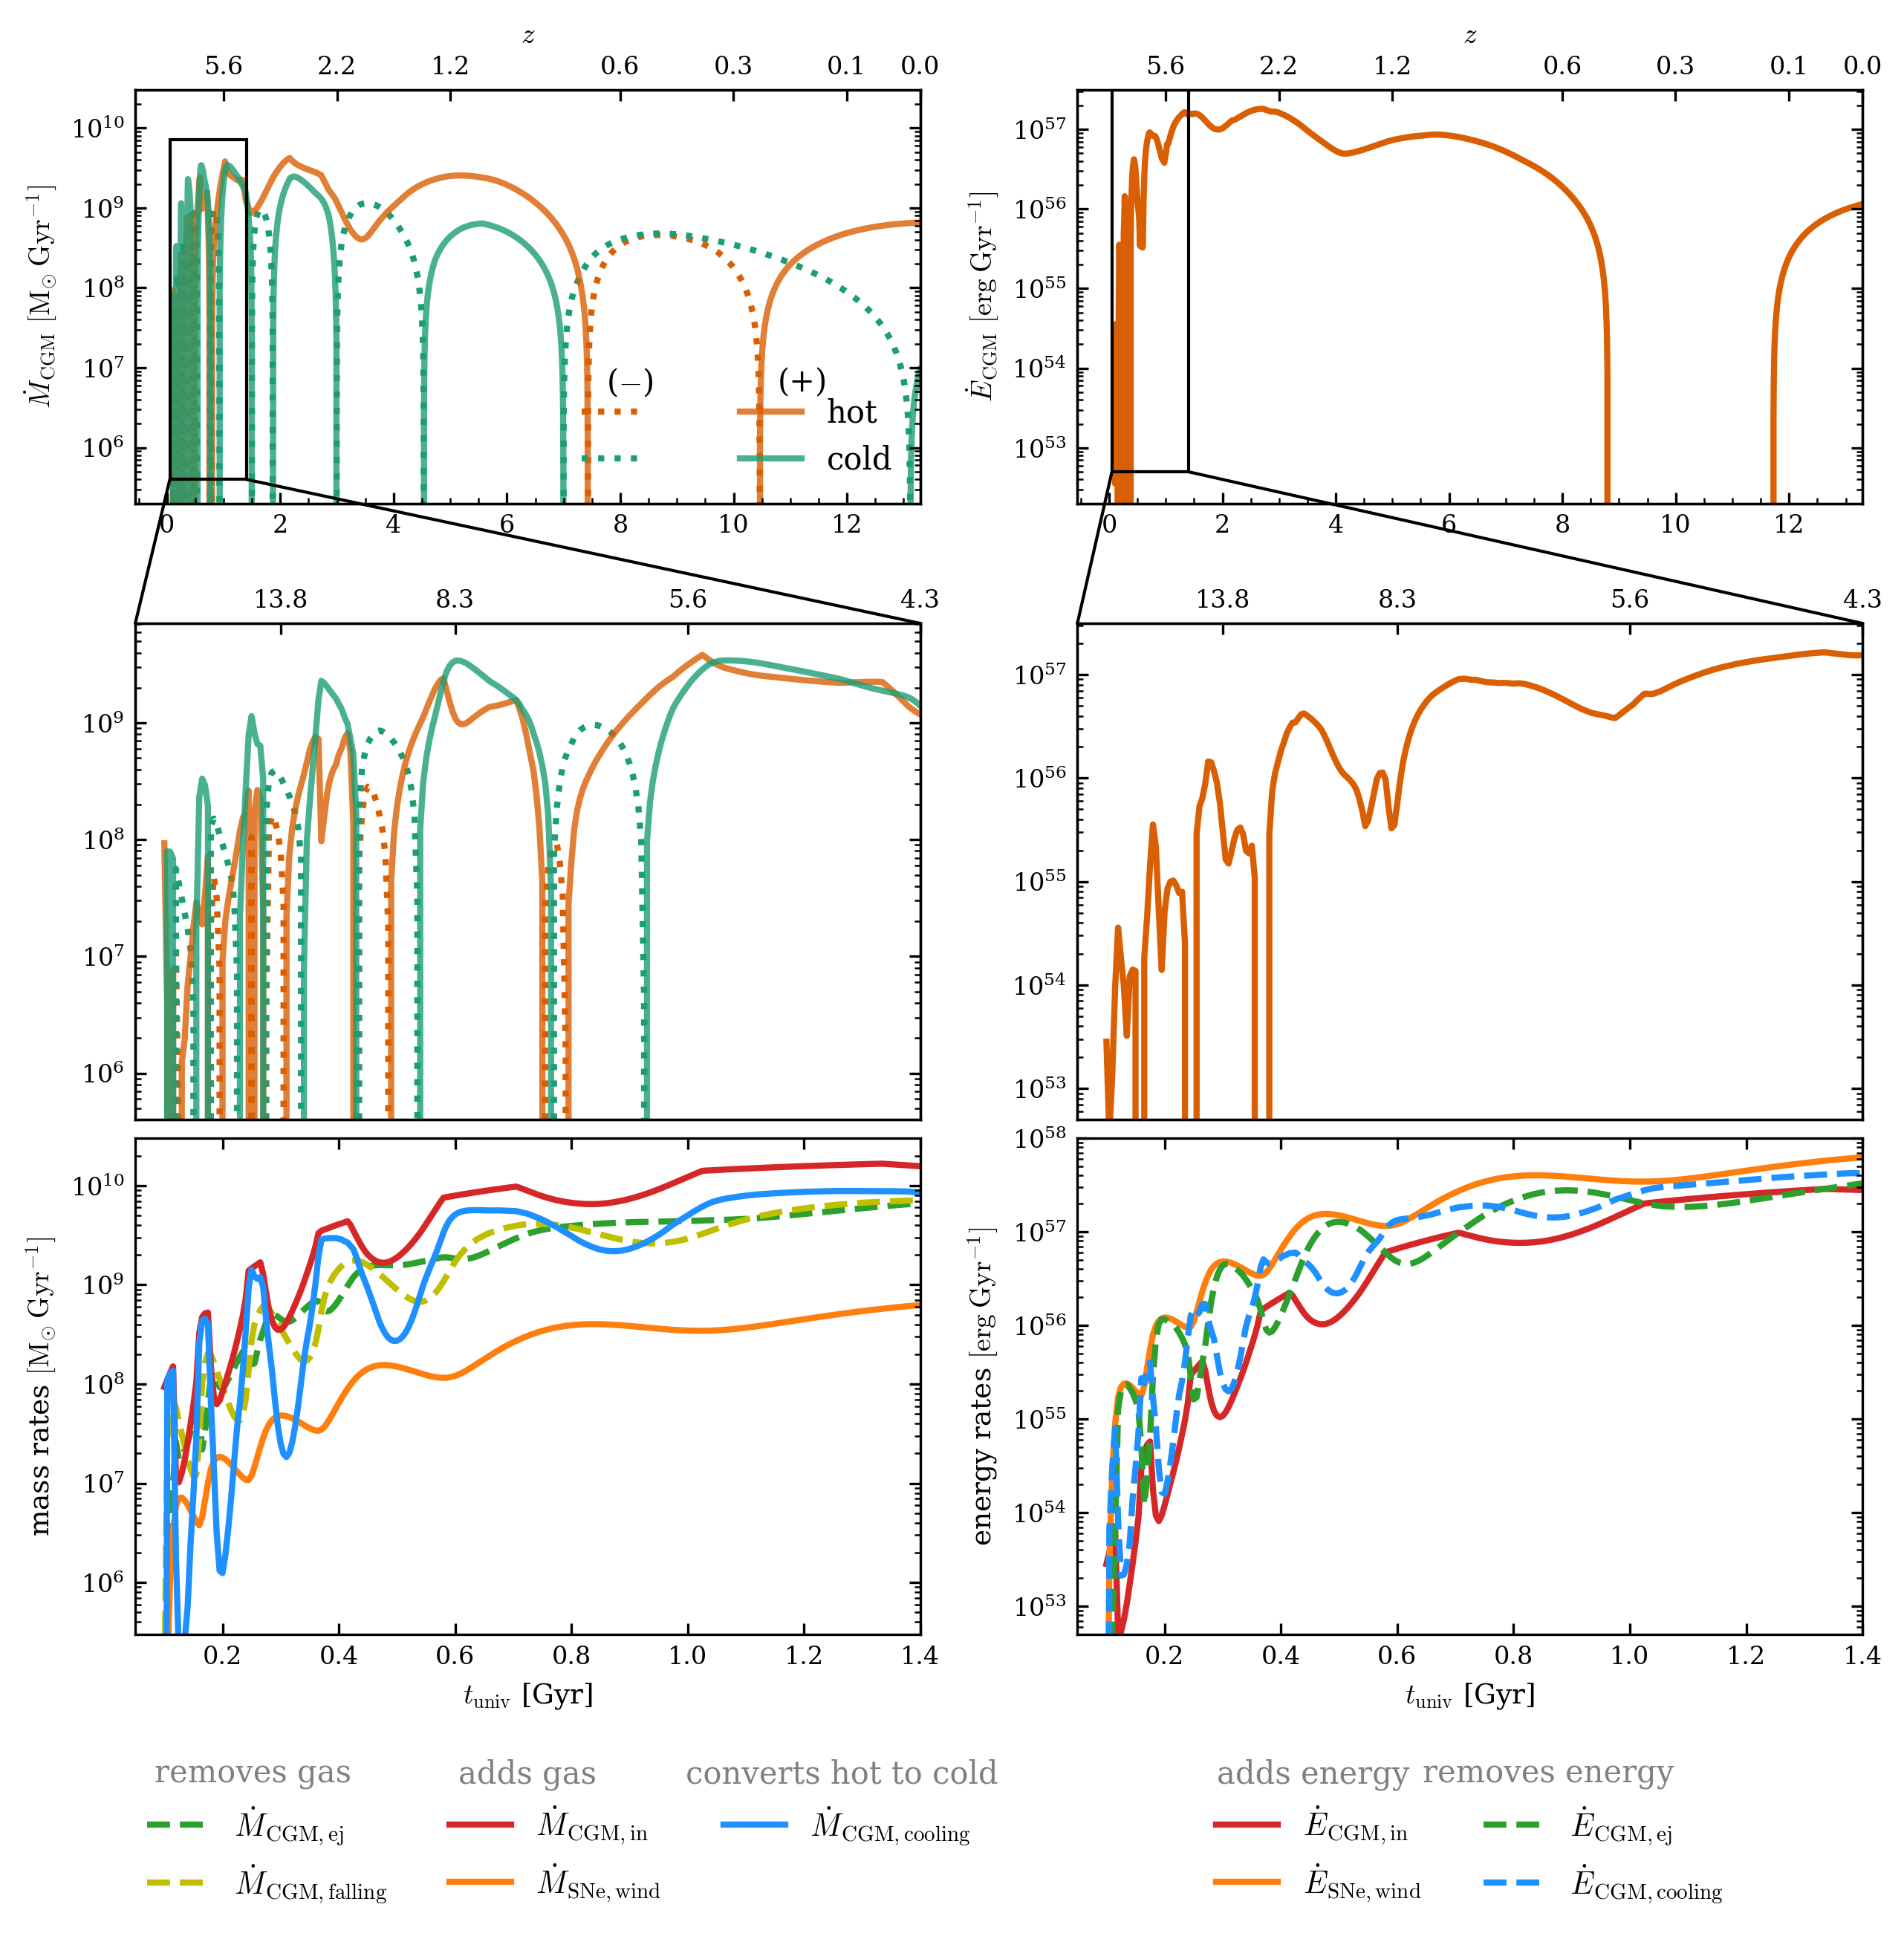

In [12]:
tmin = results_2phase["t"].min() * 0.1
tmax = results_2phase["t"].max()

red1 = "tab:red"
red2 = "tab:orange"
blu1 = "dodgerblue"
blu2 = "tab:green"

fig, ax = plt.subplots(
    4,
    2,
    figsize=(10, 9),
    dpi=300,
    gridspec_kw={"height_ratios": [2.5, 0.5, 3, 3]},
)
plt.subplots_adjust(hspace=0.05, wspace=0.2)
ax = ax.flatten()

cmap = plt.get_cmap("Dark2")
hot_clr = cmap(1)
col_clr = cmap(0)

cmapdark2 = plt.get_cmap("Dark2")
total_clr = cmapdark2(0)

# Panel 0: CGM mass rates
# let's also include the negative values and take absolute values and have that as dotted line
# neg_dot_m_cgm_hot_mask = derived_2phase["dot_m_cgm_hot"] < 0
# neg_dot_m_cgm_cold_mask = derived_2phase["dot_m_cgm_cold"] < 0

time_hot = results_2phase["t"]  # [neg_dot_m_cgm_hot_mask]
time_cold = results_2phase["t"]  # [neg_dot_m_cgm_cold_mask]

y_hot = -derived_2phase["dot_m_cgm_hot"]  # [neg_dot_m_cgm_hot_mask]
y_cold = -derived_2phase["dot_m_cgm_cold"]  # [neg_dot_m_cgm_cold_mask]

ax[0].plot(time_hot, y_hot, color=hot_clr, lw=2, ls=":", label=" ")

ax[0].plot(time_cold, y_cold, color=col_clr, lw=2, ls=":", label=" ")

ax[4].plot(time_hot, y_hot, color=hot_clr, lw=2, ls=":", label="")

ax[4].plot(time_cold, y_cold, color=col_clr, lw=2, ls=":", label="")

ax[0].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_hot"],
    color=hot_clr,
    lw=2,
    label=r"hot",
    alpha=0.8,
)
ax[0].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_cold"],
    color=col_clr,
    lw=2,
    label=r"cold",
    alpha=0.8,
)

ax[0].legend(frameon=False, ncol=2, loc="lower right", fontsize=10)
ax[0].set(
    ylabel=r"$\dot{M}_{\rm CGM}  ~ [{\rm M_{\odot}}\: {\rm Gyr^{-1}}]$",
    yscale="log",
    ylim=(2e5, 3e10),
)
ax[0].text(
    0.63,
    0.33,
    r"($-$)",
    transform=ax[0].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="k",
)
ax[0].text(
    0.85,
    0.33,
    r"(+)",
    transform=ax[0].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="k",
)

# Panel 3: CGM mass rates (inset range)
ax[4].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_hot"],
    color=hot_clr,
    lw=2,
    alpha=0.8,
    label=r"$\dot{M}_{\rm CGM, hot}$",
)
ax[4].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_cold"],
    color=col_clr,
    lw=2,
    alpha=0.8,
    label=r"$\dot{M}_{\rm CGM, cold}$",
)
ax[4].set(yscale="log", xlim=(0.05, 1.4), ylim=(4e5, None))

# Panel 1: CGM energy rates
dot_e_sne_wind = derived_2phase["dot_e_ism_wind"]
dot_e_cgm_acc = derived_2phase["dot_e_cgm_in"]
dot_e_cgm_cool = derived_2phase["dot_e_cgm_cooling"]
dot_e_cgm_ej = derived_2phase["dot_e_cgm_out"]
dot_e_cgm_total = dot_e_cgm_acc + dot_e_sne_wind - dot_e_cgm_ej - dot_e_cgm_cool

ax[1].plot(
    results_2phase["t"],
    dot_e_cgm_total,
    color=hot_clr,
    lw=2,
    # label=r"$\dot{E}_{\rm CGM, total}$",
)
ax[1].set(
    ylabel=r"$\dot{E}_{\rm CGM}~ [{\rm erg\: Gyr^{-1}}]$",
    yscale="log",
    ylim=(2e52, None),
)
# ax[1].legend(frameon=False, ncol=1, loc="lower right")

# Panel 4: CGM energy rates (inset range)
ax[5].plot(
    results_2phase["t"],
    dot_e_cgm_total,
    color=hot_clr,
    lw=2,
    label=r"$\dot{E}_{\rm CGM}$",
)
ax[5].set(yscale="log", xlim=(0.05, 1.4), ylim=(5e52, None))

# --- Custom connectors ---
# Connector 1: top-left of zoom region in parent → top-left corner of inset
con1 = ConnectionPatch(
    xyA=(0, 1),
    coordsA=ax[5].transAxes,
    xyB=(0.05, 5e52),
    coordsB=ax[1].transData,
    color="k",
    lw=1,
    zorder=10,
)

# Connector 2: bottom-right of zoom region in parent → bottom-right corner of inset
con2 = ConnectionPatch(
    xyA=(1, 1),
    coordsA=ax[5].transAxes,
    xyB=(1.4, 5e52),
    coordsB=ax[1].transData,
    color="k",
    lw=1,
    zorder=10,
)
ax[1].figure.add_artist(con1)
ax[1].figure.add_artist(con2)
artists = mark_inset(
    ax[1],
    ax[5],
    loc1=2,
    loc2=4,
    fc="none",
    color="k",
    zorder=10,
)
for line in artists[1:]:
    line.set_alpha(0.0)

# Connector 1: top-left of zoom region in parent → top-left corner of inset
con1 = ConnectionPatch(
    xyA=(0, 1),
    coordsA=ax[4].transAxes,  # UL corner of inset
    xyB=(0.05, 4e5),
    coordsB=ax[0].transData,  # UL of parent zoom
    color="k",
    lw=1,
    zorder=10,
)
ax[0].figure.add_artist(con1)

# Connector 2: bottom-right of zoom region in parent → bottom-right corner of inset
con2 = ConnectionPatch(
    xyA=(1, 1),
    coordsA=ax[4].transAxes,  # LR corner of inset
    xyB=(1.4, 4e5),
    coordsB=ax[0].transData,  # LR of parent zoom
    color="k",
    lw=1,
    zorder=10,
)
ax[0].figure.add_artist(con2)

# --- Draw rectangle only, hide default connectors ---
artists = mark_inset(ax[0], ax[4], loc1=2, loc2=4, fc="none", color="k", zorder=10)
for line in artists[1:]:
    line.set_alpha(0.0)

# Panels 2 and 3: ghost rows for spacing only, no plots
ax[2].axis("off")
ax[3].axis("off")

# Panel 4: CGM mass rates (zoomed)
dot_m_cgm_cooling = results_2phase["m_cgm_hot"] / derived_2phase["tcool_real"]
dot_m_cgm_in = derived_2phase["dot_m_cgm_in"]
dot_m_sne_wind = derived_2phase["dot_m_ism_wind"]
dot_m_cgm_ej = derived_2phase["dot_m_cgm_out"]
dot_cgm_falling = results_2phase["m_cgm_cold"] / derived_2phase["t_dynamical"]

ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_ej,
    lw=2,
    ls="--",
    label=r"$\dot{M}_{\rm CGM, ej}$",
    color=blu2,
)
ax[6].plot(
    results_2phase["t"],
    dot_cgm_falling,
    lw=2,
    ls="--",
    label=r"$\dot{M}_{\rm CGM, falling}$",
    color="y",
)

ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_in,
    lw=2,
    label=r"$\dot{M}_{\rm CGM, in}$",
    color=red1,
)
ax[6].plot(
    results_2phase["t"],
    dot_m_sne_wind,
    lw=2,
    label=r"$\dot{M}_{\rm SNe, wind}$",
    color=red2,
)


ax[6].set(
    ylabel=r"mass rates $[{\rm M_{\odot}}\: {\rm Gyr^{-1}}]$",
    yscale="log",
    ylim=(3e5, 3e10),
    xlabel=r"$t_{\rm univ}$ [Gyr]",
    xlim=(0.05, 1.4),
)
ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_cooling,
    lw=2,
    ls="-",
    label=r"$\dot{M}_{\rm CGM, cooling}$",
    color=blu1,
)
ax[6].legend(
    frameon=False, ncol=3, fontsize=10, loc="lower right", bbox_to_anchor=(1.1, -0.6)
)

ax[6].text(
    0.15,
    -0.25,
    r"removes gas",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[6].text(
    0.5,
    -0.25,
    r"adds gas",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[6].text(
    0.9,
    -0.25,
    "converts hot to cold",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)

# Panel 5: CGM energy rates (zoomed)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_acc,
    color=red1,
    lw=2,
    label=r"$\dot{E}_{\rm CGM, in}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_sne_wind,
    color=red2,
    lw=2,
    label=r"$\dot{E}_{\rm SNe, wind}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_ej,
    color=blu2,
    lw=2,
    ls="--",
    label=r"$\dot{E}_{\rm CGM, ej}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_cool,
    color=blu1,
    ls="--",
    lw=2,
    label=r"$\dot{E}_{\rm CGM, cooling}$",
)
ax[7].set(
    ylabel=r"energy rates $[{\rm erg\: Gyr^{-1}}]$",
    yscale="log",
    ylim=(5e52, 1e58),
    xlim=(0.05, 1.4),
    xlabel=r"$t_{\rm univ}$ [Gyr]",
)
ax[7].legend(
    frameon=False, ncol=2, fontsize=10, loc="lower center", bbox_to_anchor=(0.5, -0.6)
)

# first column of the legend add energy to the CGM , 2nd removes, add text annotation
ax[7].text(
    0.3,
    -0.25,
    r"adds energy",
    transform=ax[7].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[7].text(
    0.6,
    -0.25,
    r"removes energy",
    transform=ax[7].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)

# make a twin redshift axis for the top row, using z
t_ticks = np.array([1, 3, 5, 8, 10, 12, 13.3])
z_ticks = [cosmology.z_at_value(LCDM.age, t * u.Gyr).value for t in t_ticks]

for i in [0, 1]:
    ax2 = ax[i].twiny()
    ax2.plot(results_2phase["t"], derived_2phase["dot_m_cgm_hot"], color="k", alpha=0)
    ax2.set_xlim((None, tmax))
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels(["{:.1f}".format(z) for z in z_ticks])
    ax2.set_xlabel(r"$z$")
    ax2.minorticks_off()
    ax[i].minorticks_on()
    ax[i].set_xlim((None, tmax))

t_ticks = np.array([0.3, 0.6, 1, 1.4])
z_ticks = [cosmology.z_at_value(LCDM.age, t * u.Gyr).value for t in t_ticks]
for i in [4, 5]:
    ax2 = ax[i].twiny()
    ax2.plot(results_2phase["t"], derived_2phase["dot_m_cgm_hot"], color="k", alpha=0)
    ax2.set_xlim((0.05, 1.4))
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels(["{:.1f}".format(z) for z in z_ticks])
    # ax2.set_xlabel(r"$z$")
    ax2.minorticks_off()
    ax[i].minorticks_on()
    ax[i].set_xlim((0.05, 1.4))
    # turn x axis ticks off
    ax[i].set_xticks([])

for axes in ax:
    for line in axes.lines:
        line.set_zorder(1)

# plt.savefig(
#     "./figures/fig_2phase_detailed_cgm_1e12.png",
#     dpi=200,
#     bbox_inches="tight",
#     pad_inches=0.05,
# )
plt.show()